# HAWK Hochschule für angewandte Wissenschaft und Kunst - Mapping

In [2]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [4]:
client = bigquery.Client(project='subugoe-collaborative')

In [5]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS fak_name,
                        'HAWK Hochschule für angewandte Wissenschaft und Kunst' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202603` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202603` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/00f5q5839' -- 'HAWK Hochschule für angewandte Wissenschaft und Kunst'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [6]:
oal.head()

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,HAWK Hochschule für angewandte Wissenschaft un...,"Faculty of Resource Management, University of ...",https://openalex.org/W4213284996
1,not assigned,HAWK Hochschule für angewandte Wissenschaft un...,"Faculty of Resource Management, HAWK Universit...",https://openalex.org/W4282034350
2,not assigned,HAWK Hochschule für angewandte Wissenschaft un...,"HAWK Hildesheim, Hildesheim, Deutschland",https://openalex.org/W4416651319
3,not assigned,HAWK Hochschule für angewandte Wissenschaft un...,Fakultät Ingenieurwissenschaften und Gesundhei...,https://openalex.org/W4281670500
4,not assigned,HAWK Hochschule für angewandte Wissenschaft un...,"University of Applied Sciences and Arts, Facul...",https://openalex.org/W4313199144


In [32]:
MAPPING_DICT = {
    #'HAWK plus Entrepreneurship': [],
    'Fakultät Ingenieurwissenschaften und Gesundheit': ['plasma', 'eng(.|n|ine(e)?ring) (and|&) h(ea)?lth', 'ingenieurwissenschaften und (gesundheit|technik)',
                                                        'sciences and technology', 'fluidmechanics', '(health |gesundheits)campus', 'faculty of science and art',
                                                        'therapieforschung', 'engineering science and health'
                                                       ],
    'Fakultät Ressourcenmanagement': ['resource mana(na)?gement', 'faculty of management', 'fakultät management', 'ressourcenmanagement'],
    'Fakultät Bauen und Erhalten': ['architecture', 'bauen und erhalten'],
    'Fakultät Gestaltung': ['design', 'gestaltung'],
    'Fakultät soziale Arbeit und Gesundheit': ['soziale arbeit', 'social work'],
    #'Fakultät Management, Soziale Arbeit, Bauen': []
}

In [33]:
with open('./mapping_tables_fak/hawk.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT, f, ensure_ascii=False)

In [34]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [35]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned', 'fak_name'] = \
           df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [36]:
df_with_inst

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,Fakultät Ressourcenmanagement,HAWK Hochschule für angewandte Wissenschaft un...,"Faculty of Resource Management, University of ...",https://openalex.org/W4213284996
1,Fakultät Ressourcenmanagement,HAWK Hochschule für angewandte Wissenschaft un...,"Faculty of Resource Management, HAWK Universit...",https://openalex.org/W4282034350
2,None,HAWK Hochschule für angewandte Wissenschaft un...,"HAWK Hildesheim, Hildesheim, Deutschland",https://openalex.org/W4416651319
3,Fakultät Ingenieurwissenschaften und Gesundheit,HAWK Hochschule für angewandte Wissenschaft un...,Fakultät Ingenieurwissenschaften und Gesundhei...,https://openalex.org/W4281670500
4,Fakultät Ingenieurwissenschaften und Gesundheit,HAWK Hochschule für angewandte Wissenschaft un...,"University of Applied Sciences and Arts, Facul...",https://openalex.org/W4313199144
...,...,...,...,...
535,None,HAWK Hochschule für angewandte Wissenschaft un...,"University of Applied Sciences and Arts, Von-O...",https://openalex.org/W3048022605
536,None,HAWK Hochschule für angewandte Wissenschaft un...,"University of Applied Sciences and Arts, Von-O...",https://openalex.org/W3048022605
537,Fakultät soziale Arbeit und Gesundheit,HAWK Hochschule für angewandte Wissenschaft un...,"Fakultät Soziale Arbeit und Gesundheit, Bachel...",https://openalex.org/W4200443683
538,Fakultät Ingenieurwissenschaften und Gesundheit,HAWK Hochschule für angewandte Wissenschaft un...,"Faculty of Engineering and Health, University ...",https://openalex.org/W3084121006


In [37]:
df_with_inst[df_with_inst.fak_name.isnull()].raw_affiliation_string.unique()

array(['HAWK Hildesheim, Hildesheim, Deutschland',
       'Hochschule für angewandte Wissenschaft und Kunst\n                    Hildesheim/Holzminden/Göttingen',
       'University of Applied Sciences Giessen, Institute of Medical Physics and Radiation Protection, Giessen, Germany; University Medical Center Göttingen, Department of Radiation Oncology, Göttingen, Germany',
       'Department for Knowledge and Technology Transfer, University of Applied Sciences and Arts, Hohnsen 4, 31134 Hildesheim, Germany',
       'HAWK Hochschule für angewandte Wissenschaft und Kunst Hildesheim/Holzminden/Göttingen – Technische Hochschule Ostwestfalen-Lippe, Göttingen, Germany',
       'Hochschule für angewandte Wissenschaft und Kunst Hildesheim/Holzminden/Göttingen (HAWK), Fakultät In',
       'HAWK Hochschule für angewandte Wissenschaft und Kunst Hildesheim/Holzminden/Göttingen',
       'HAWK – Hochschule für Angewandte Wissenschaften und Kunst Hildesheim',
       'HAWK University of Applied Scienc

In [38]:
df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()

,fak_name,openalex_id
0,Fakultät Bauen und Erhalten,2
1,Fakultät Gestaltung,6
2,Fakultät Ingenieurwissenschaften und Gesundheit,171
3,Fakultät Ressourcenmanagement,156
4,Fakultät soziale Arbeit und Gesundheit,77
5,NaN,128


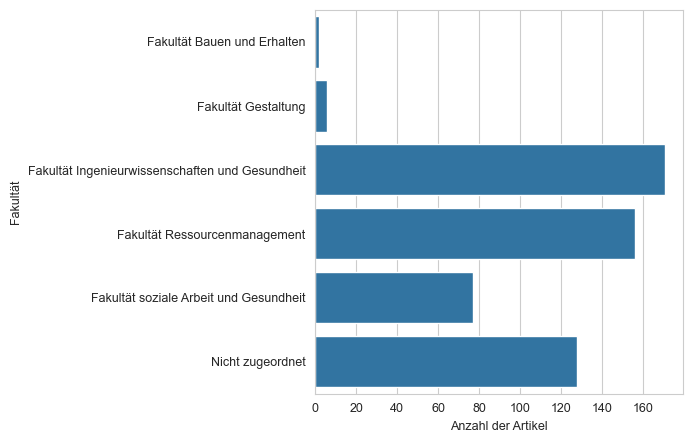

In [39]:
df_plot = df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='fak_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [40]:
df_plot[df_plot.fak_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.762962962962963

In [41]:
MAPPING_DICT_DEPT = {}
MAPPING_DICT_INST = {}

In [42]:
gerit_ids = pd.read_csv('../../data/gerit_inst_with_ids.csv')
gerit_ids = gerit_ids[gerit_ids.parent_name == 'HAWK Hochschule für angewandte Wissenschaft und Kunst'][['inst_name', 'dfg_id']].to_dict(orient='records')

def search_gerit_id(name: str):  
    for gerit_id in gerit_ids:
        if gerit_id['inst_name'] == name:
            return gerit_id.get('dfg_id')

uni_dicts = dict()

for faculty, faculty_patterns in MAPPING_DICT.items():

    faculty_dict = dict()

    faculty_dict['faculty_id'] = search_gerit_id(faculty)
    faculty_dict['faculty_patterns'] = faculty_patterns

    faculty_suborganisations = dict()
    
    if MAPPING_DICT_DEPT.get(faculty):
        for department, department_patterns in MAPPING_DICT_DEPT.get(faculty).items():

            department_dict = dict()
            
            department_dict['department_id'] = search_gerit_id(department)
            department_dict['department_patterns'] = department_patterns

            department_suborganisations = dict()
            
            if MAPPING_DICT_INST.get(department):
                for institute, institute_patterns in MAPPING_DICT_INST.get(department).items():

                    institute_dict = dict()
            
                    institute_dict['institute_id'] = search_gerit_id(institute)
                    institute_dict['institute_patterns'] = institute_patterns

                    department_suborganisations[institute] = institute_dict
                    
            department_dict['suborganisations'] = department_suborganisations

            faculty_suborganisations[department] = department_dict

    faculty_dict['suborganisations'] = faculty_suborganisations

    uni_dicts[faculty] = faculty_dict

with open('../../data/mappings/hawk.json', mode='w', encoding='utf-8') as f:
    json.dump(uni_dicts, f, ensure_ascii=False)